<a href="https://colab.research.google.com/github/juliacporto-creator/Estatistica-/blob/main/tarefa04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- Julia Porto - 17901372
- Larissa Mei - 17903839
- Marianne Adorno - 17995367

In [ ]:
import pandas as pd
pd.set_option('display.max_rows', None) # Set option to display all rows
df_tarefa4 = pd.read_excel("tarefa4.xlsx") # Ensure df_tarefa4 is defined
display(df_tarefa4)

,Nº de identificação,Município de notificação,UF de notificação,Região,Data da notificação,Ano de notificação,1º Agente etiológico do surto,2º Agente etiológico do surto,3º Agente etiológico do surto,Alimento causador do surto,Local de ocorrência do surto,N° total de casos expostos,Nº total de doentes,Nº de óbitos,Critério de confirmação do surto
0,354,PARQUE DA BARRAGEM,DF,Centro-oeste,05/05/2000,2000.0,Ignorado,NaN,NaN,Alimentos mistos,Eventos,70.0,50.0,0.0,Ignorado
1,355,SAPIRANGA,RS,Sul,22/05/2000,2000.0,Salmonella spp,NaN,NaN,Ovos e produtos à base de ovos,Residência,0.0,0.0,0.0,Ignorado
2,356,VENANCIO AIRES,RS,Sul,22/05/2000,2000.0,Salmonella spp,NaN,NaN,Ovos e produtos à base de ovos,Residência,0.0,12.0,0.0,Ignorado
3,357,PLANALTO,RS,Sul,22/05/2000,2000.0,Ignorado,NaN,NaN,Ovos e produtos à base de ovos,Residência,0.0,0.0,0.0,Ignorado
4,358,SANTA ROSA,RS,Sul,22/05/2000,2000.0,Salmonella spp,NaN,NaN,Ovos e produtos à base de ovos,Residência,0.0,11.0,0.0,Ignorado
5,359,BENTO GONCALVES,RS,Sul,22/05/2000,2000.0,Salmonella spp,NaN,NaN,"Cereais, farináceos e produtos a base de cereais",Residência,0.0,2.0,0.0,Ignorado
6,360,MARQUES DE SOUZA,RS,Sul,22/05/2000,2000.0,Salmonella spp,NaN,NaN,Ovos e produtos à base de ovos,"Outras Instituições (alojamento,trabalho)",0.0,4.0,0.0,Ignorado
7,361,BARRA DA GUARITA,RS,Sul,22/05/2000,2000.0,Ignorado,NaN,NaN,Ignorado,Residência,0.0,0.0,0.0,Ignorado
8,362,SANTO ANTONIO PLANALTO,RS,Sul,22/05/2000,2000.0,Salmonella spp,NaN,NaN,Ovos e produtos à base de ovos,Residência,0.0,10.0,0.0,Ignorado
9,363,GARIBALDI,RS,Sul,22/05/2000,2000.0,Salmonella spp,NaN,NaN,Ovos e produtos à base de ovos,Residência,0.0,3.0,0.0,Ignorado


#Fonte:

BRASIL. Ministério da Saúde. Situação epidemiológica das doenças transmitidas por alimentos. Brasília, DF: Ministério da Saúde, [s.d.]. Disponível em: Ministério da Saúde — Situação epidemiológica. Acesso em: 15 ago. 2026.

BRASIL. Ministério da Saúde. Dados de surtos de doenças de transmissão hídrica e alimentar (DTHA): 2000–2023. Brasília, DF: Ministério da Saúde, [s.d.]. Disponível em: Planilha Dados Surtos de DTHA – 2000 a 2023. Acesso em: 15 ago. 2026.

Primeiro quartil (Q1): 3
Segundo quartil (Q2 - Mediana): 7
Terceiro quartil (Q3): 20
Amplitude interquartil (AIQ): 17
Limite inferior: -22.50
Limite superior: 45.50

Quantidade de observações atípicas: 486


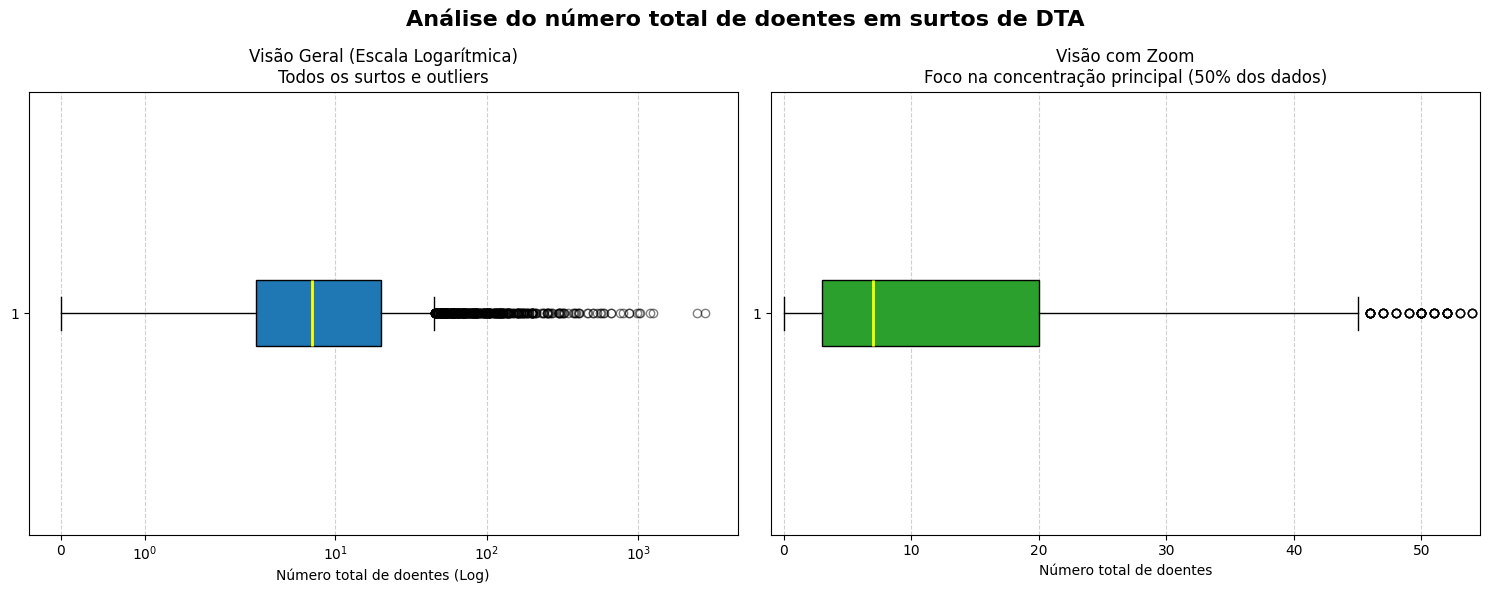

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("tarefa4.xlsx")

variavel = df['Nº total de doentes    '].dropna()

Q1 = variavel.quantile(0.25)
Q2 = variavel.quantile(0.50)
Q3 = variavel.quantile(0.75)
AIQ = Q3 - Q1

limite_inferior = Q1 - 1.5 * AIQ
limite_superior = Q3 + 1.5 * AIQ

print(f"Primeiro quartil (Q1): {Q1:.0f}")
print(f"Segundo quartil (Q2 - Mediana): {Q2:.0f}")
print(f"Terceiro quartil (Q3): {Q3:.0f}")
print(f"Amplitude interquartil (AIQ): {AIQ:.0f}")
print(f"Limite inferior: {limite_inferior:.2f}")
print(f"Limite superior: {limite_superior:.2f}")

atipicos = variavel[(variavel < limite_inferior) | (variavel > limite_superior)]
print(f"\nQuantidade de observações atípicas: {len(atipicos)}")

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

axes[0].boxplot(variavel, vert=False, patch_artist=True,
                boxprops=dict(facecolor='#1f77b4', color='black'),
                medianprops=dict(color='yellow', linewidth=2),
                flierprops=dict(marker='o', color='red', alpha=0.5))
axes[0].set_xscale('symlog')
axes[0].set_title("Visão Geral (Escala Logarítmica)\nTodos os surtos e outliers")
axes[0].set_xlabel("Número total de doentes (Log)")
axes[0].grid(axis='x', linestyle='--', alpha=0.6)

axes[1].boxplot(variavel, vert=False, patch_artist=True,
                boxprops=dict(facecolor='#2ca02c', color='black'),
                medianprops=dict(color='yellow', linewidth=2),
                flierprops=dict(marker='o', color='red', alpha=0.5))

axes[1].set_xlim(left=-1, right=limite_superior * 1.2)
axes[1].set_title("Visão com Zoom\nFoco na concentração principal (50% dos dados)")
axes[1].set_xlabel("Número total de doentes")
axes[1].grid(axis='x', linestyle='--', alpha=0.6)

plt.suptitle("Análise do número total de doentes em surtos de DTA", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#Definições:

##Quartis:

Quartis são medidas de localização, denotadas por Q1, Q2 e Q3, que dividem um conjunto de dados em quatro grupos, com cerca de 25% dos valores em cada grupo.

Q1 (Primeiro quartil):
mesmo valor de P25. Separa os 25% inferiores dos 75% valores ordenados superiores. (Mais precisamente, pelo menos 25% dos valores ordenados são menores ou iguais a Q1, e, no mínimo, 75% dos valores são maiores ou iguais a Q1.)

Q2 (Segundo quartil):
mesmo que P50 e mesmo que a mediana. Separa os 50% valores ordenados inferiores dos 50% superiores.

Q3 (Terceiro quartil):
mesmo que P75. Separa os 75% valores ordenados inferiores dos 25% superiores. (Mais precisamente, no mínimo 75% dos valores ordenados são menores ou iguais a Q3, e, no mínimo, 25% dos valores são maiores ou iguais a Q3.)



##Mediana:

A mediana de um conjunto de dados é a medida de centro que é o valor do meio quando os dados originais estão arranjados em ordem crescente (ou decrescente) de magnitude.



##Amplitude interquartílica:
é uma medida de dispersão estatística que indica a variação dos 50% centrais de um conjunto de dados. Ela é calculada subtraindo o primeiro quartil do terceiro quartil.


##Boxplot:
Um diagrama em caixa ou boxplot (ou diagrama em caixa e bigode) é um gráfico de um conjunto de dados que consiste em uma linha que se estende do valor mínimo ao valor máximo, e em uma caixa com linhas traçadas no primeiro quartil, Q1, na mediana e no terceiro quartil, Q3.

##Observaçes Atípicas
Ou outliers ou valores Atípicos, são valores amostrais que estão muito distantes da maioria dos outros.


#Fonte:
TRIOLA, Mario F. Introdução à Estatística. 14. ed. Rio de Janeiro: LTC, 2024. E-book. p.734. ISBN 9788521638780. Disponível em: https://app.minhabiblioteca.com.br/reader/books/9788521638780/. Acesso em: 15 ago. 2026.



#Relação entre os conceitos e os gráficos:

##Mediana (Q2):
 A linha amarela dentro da caixa verde no gráfico 2 representa a Mediana, que é o valor central (7 doentes) que divide os dados em duas metades iguais. Metade dos surtos teve 7 ou menos doentes, e a outra metade teve 7 ou mais.

##Quartis (Q1 e Q3):
 As extremidades da caixa verde no gráfico 2 correspondem ao Primeiro Quartil (Q1 = 3 doentes) e ao Terceiro Quartil (Q3 = 20 doentes). A caixa em si engloba os 50% centrais dos dados, ou seja, a maioria dos surtos de DTA. 25% dos surtos tiveram até 3 doentes e 75% dos surtos tiveram até 20 doentes.


##Amplitude Interquartílica (AIQ):
 É a largura da caixa verde no gráfico 2 (AIQ = Q3 - Q1 = 17). Essa medida mostra a dispersão dos 50% centrais dos dados, indicando que a variação mais comum no número de doentes entre surtos é de 17 pessoas.


##Observações Atípicas (Outliers):
 No Gráfico 1 (Visão Geral), os pontos que se estendem muito além dos "bigodes" (linhas pretas finas) são as Observações Atípicas. Esses são os surtos com um número excepcionalmente alto de doentes, muito distantes do padrão típico. A análise mostrou que temos 486 dessas observações, indicando que, embora a maioria dos surtos seja pequena, existem eventos de grande escala que distorcem a distribuição.
 Os "bigodes" do boxplot são determinados pelos limites inferior e superior, sendo que quaisquer pontos fora desses limites são considerados outliers. O Gráfico 2 foca na região dentro desses limites (excluindo os outliers para melhor visualização da concentração), enquanto o Gráfico 1 mostra todos os dados, incluindo os outliers, com uma escala logarítmica para acomodar a vasta gama de valores.


#1. Cenário Típico: O "Micro-Surto" Familiar ou Local
Olhando para o Gráfico 2 (Visão com Zoom), vemos a caixa verde que concentra 50% de todos os dados.

A Mediana é 7: Isso significa que em metade de todos os surtos registrados, o número de doentes foi de apenas 1 a 7 pessoas.

O 3º Quartil é 20: 75% de todos os surtos de DTA na sua base afetaram no máximo 20 pessoas.

A esmagadora maioria dos problemas com alimentos no Brasil é altamente localizada. São casos clássicos de uma maionese estragada no almoço de domingo da família, um lanche contaminado consumido por um pequeno grupo de amigos em uma lanchonete, ou falhas de higiene em uma cozinha residencial. São eventos frequentes, mas de baixo impacto numérico individual.

#2. A Fronteira do "Normal": O Limite do Bigode
O limite superior estatístico do boxplot é de 45,5 doentes.

A partir de 46 pessoas doentes em um único evento, a Vigilância Epidemiológica já está lidando com algo estatisticamente anormal. Surtos desse tamanho geralmente envolvem cozinhas que preparam comida em maior escala, mas ainda contidas em um ambiente específico: festas de casamento, refeitórios de escolas, bufês de empresas ou restaurantes com alto fluxo no horário de almoço.

#3. Os "Mega-Surtos": Os Outliers
Há centenas de observações atípicas (outliers) que ultrapassam a marca de 50, 100, 500 e até chegam a quase 3.000 doentes.

Em epidemiologia de alimentos, quando centenas ou milhares de pessoas adoecem no mesmo surto geralmente representam:

Contaminação Industrial: Um lote inteiro de um alimento processado (como leite, queijo, embutidos ou doces) que foi contaminado na fábrica e distribuído para vários supermercados da cidade ou estado.

Água Contaminada: Muitas vezes classificada junto com DTA, a contaminação da rede de abastecimento de água de um município pode adoecer milhares de pessoas simultaneamente.

Eventos de Massa: Comida estragada servida em grandes festivais, feiras ou estádios.

##Como determinamos se há observações atípicas em uma base de dados?

Podemos determinar observações atípicas em uma base de dados observando os gráficos de boxplot, que mostram pontos isolados acima ou abaixo dos limites superiores e inferiores, ou realizando cálculos como da amplitude interquartil.
Calcula-se 1,5 x AIQ, e o dado será uma observação atípica se ele está acima de Q3 por um número maior que 1,5 x AIQ ou abaixo de Q1 por um número maior que 1,5 x AIQ.



Fonte:
TRIOLA, Mario F. Introdução à Estatística. 14. ed. Rio de Janeiro: LTC, 2024. E-book. p.130. ISBN 9788521638780. Disponível em: https://app.minhabiblioteca.com.br/reader/books/9788521638780/. Acesso em: 15 ago. 2026.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
